# Rainoff Rainoff MOdeling

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

np.random.seed(42)
tf.random.set_seed(42)

In [61]:
import seaborn as sns

In [2]:
df = pd.read_csv("rainfall_runoff.csv")
df.head(3)

,date,rainfall_mm,temperature_c,humidity_pct,pressure_hpa,wind_speed_kmh,soil_moisture_pct,evaporation_mm,previous_flow_m3s,rainfall_lag_1,rainfall_lag_2,rainfall_lag_3,flow_lag_1,flow_lag_2,flow_lag_3,runoff_m3s
0,2010-01-01,11.59,30.09,48.47,1023.76,11.13,45.00,10.40,65.00,11.59,11.59,11.59,65.00,65.0,65.0,65.00
1,2010-01-02,4.81,28.47,51.90,1008.47,7.27,38.22,8.82,65.00,11.59,11.59,11.59,65.00,65.0,65.0,57.62
2,2010-01-03,0.00,30.41,49.77,1016.21,12.42,31.09,9.18,57.62,4.81,11.59,11.59,57.62,65.0,65.0,56.37


In [3]:
df.shape

(6000, 16)

In [4]:
df.describe()

,rainfall_mm,temperature_c,humidity_pct,pressure_hpa,wind_speed_kmh,soil_moisture_pct,evaporation_mm,previous_flow_m3s,rainfall_lag_1,rainfall_lag_2,rainfall_lag_3,flow_lag_1,flow_lag_2,flow_lag_3,runoff_m3s
count,6000.000000,5970.000000,5970.000000,6000.000000,6000.000000,5970.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,6.398607,21.996598,67.930489,1013.134437,9.980018,8.02274,7.571815,39.389295,6.397592,6.399523,6.401455,39.389295,39.397127,39.403302,39.383770
std,15.124375,5.531197,11.056500,6.104148,3.468235,0.76388,1.151368,23.998557,15.123822,15.123745,15.123667,23.998557,23.999246,24.001067,23.996475
min,0.000000,7.580000,29.940000,993.010000,0.500000,8.00000,3.210000,5.000000,0.000000,0.000000,0.000000,5.000000,5.000000,5.000000,5.000000
25%,0.000000,17.440000,59.732500,1008.827500,7.560000,8.00000,6.770000,21.387500,0.000000,0.000000,0.000000,21.387500,21.405000,21.405000,21.387500
50%,0.000000,21.970000,67.885000,1013.290000,9.970000,8.00000,7.580000,36.000000,0.000000,0.000000,0.000000,36.000000,36.005000,36.010000,35.995000
75%,5.292500,26.660000,76.155000,1017.420000,12.360000,8.00000,8.380000,53.732500,5.292500,5.305000,5.320000,53.732500,53.747500,53.777500,53.685000
max,230.390000,38.590000,98.000000,1034.350000,23.800000,45.00000,11.210000,183.380000,230.390000,230.390000,230.390000,183.380000,183.380000,183.380000,183.380000


In [5]:
df.isnull().sum()

date                  0
rainfall_mm           0
temperature_c        30
humidity_pct         30
pressure_hpa          0
wind_speed_kmh        0
soil_moisture_pct    30
evaporation_mm        0
previous_flow_m3s     0
rainfall_lag_1        0
rainfall_lag_2        0
rainfall_lag_3        0
flow_lag_1            0
flow_lag_2            0
flow_lag_3            0
runoff_m3s            0
dtype: int64

In [6]:
df["temperature_c"] = df["temperature_c"].fillna(
    df["temperature_c"].mode()[0]
)
df["humidity_pct"] = df["humidity_pct"].fillna(
    df["humidity_pct"].mode()[0]
)
df["soil_moisture_pct"] = df["soil_moisture_pct"].fillna(
    df["soil_moisture_pct"].mode()[0]
)



In [7]:
df.isnull().sum()

date                 0
rainfall_mm          0
temperature_c        0
humidity_pct         0
pressure_hpa         0
wind_speed_kmh       0
soil_moisture_pct    0
evaporation_mm       0
previous_flow_m3s    0
rainfall_lag_1       0
rainfall_lag_2       0
rainfall_lag_3       0
flow_lag_1           0
flow_lag_2           0
flow_lag_3           0
runoff_m3s           0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5995    False
5996    False
5997    False
5998    False
5999    False
Length: 6000, dtype: bool

Convert date

In [9]:
import pandas as pd

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(by="date").reset_index(drop=True)

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Minimum date: 2010-01-01 00:00:00
Maximum date: 2026-06-05 00:00:00


Basic EDA

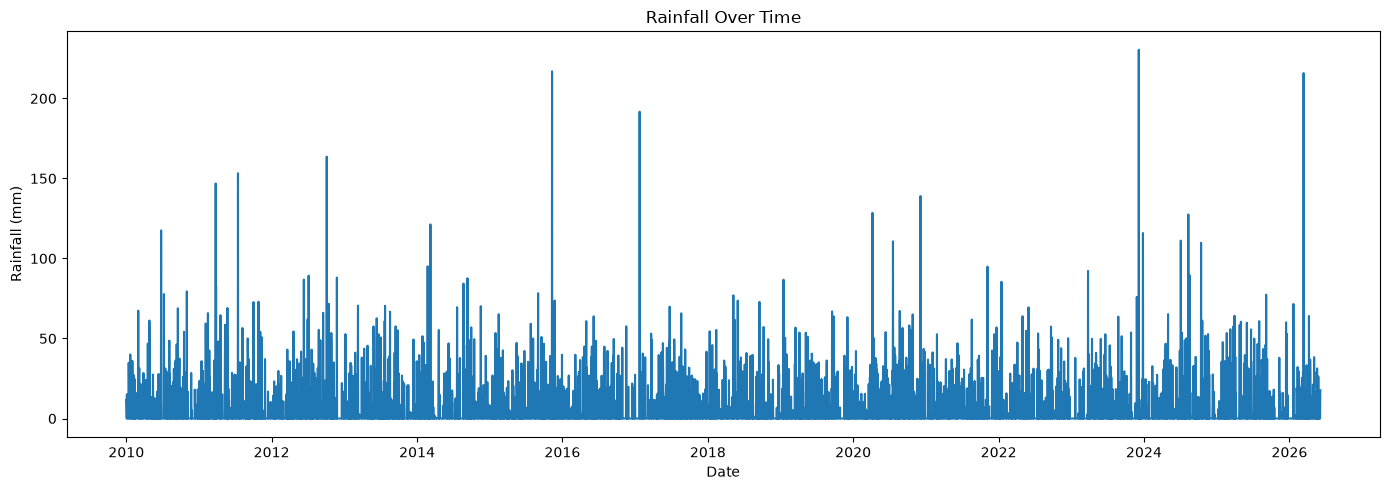

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(df["date"],df["rainfall_mm"])

plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall Over Time")

plt.tight_layout()
plt.savefig("plots/rainfall_over_time.png")
plt.show()

Runoff over time

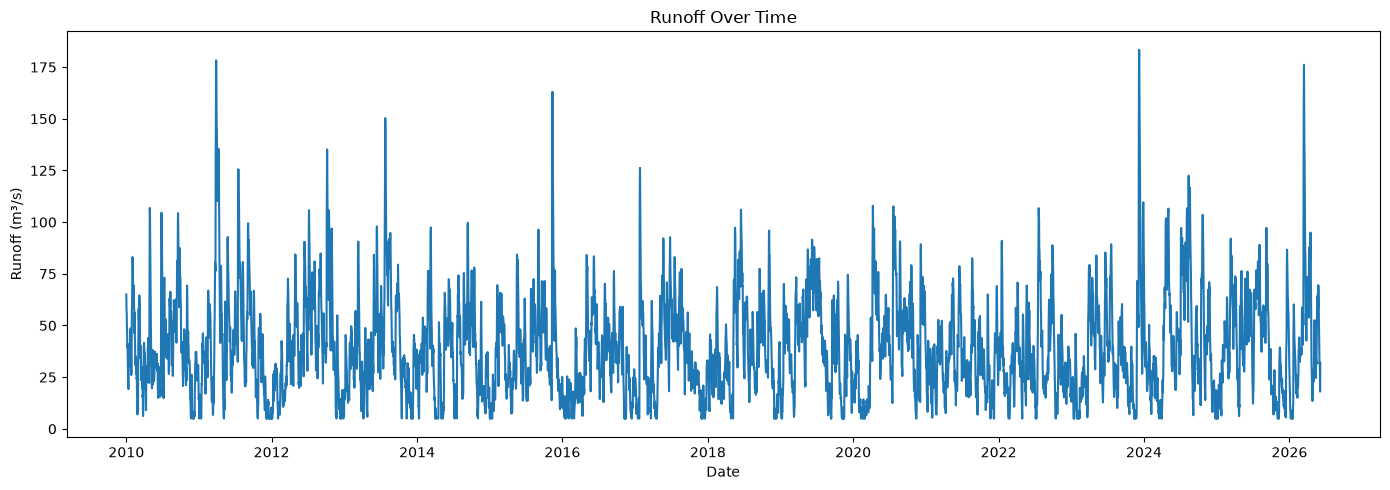

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(df["date"],df["runoff_m3s"])

plt.xlabel("Date")
plt.ylabel("Runoff (m³/s)")
plt.title("Runoff Over Time")

plt.tight_layout()
plt.savefig("plots/runoff_over_time.png")
plt.show()

# Rain Fall vs Runoff

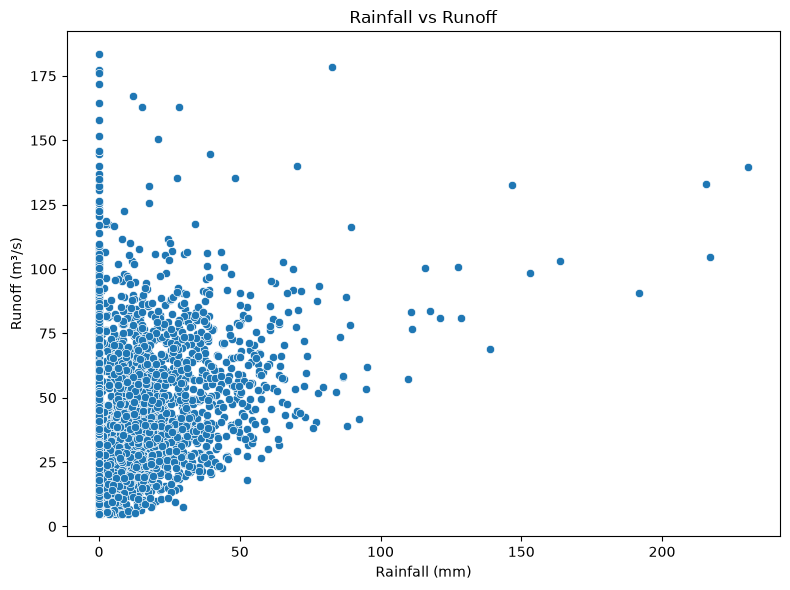

In [12]:
# Create plots folder if it doesn't exist
os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="rainfall_mm",
    y="runoff_m3s"
)

plt.title("Rainfall vs Runoff")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Runoff (m³/s)")

plt.tight_layout()
plt.savefig("plots/rainfall_vs_runoff.png")
plt.show()

Correlation heatmap

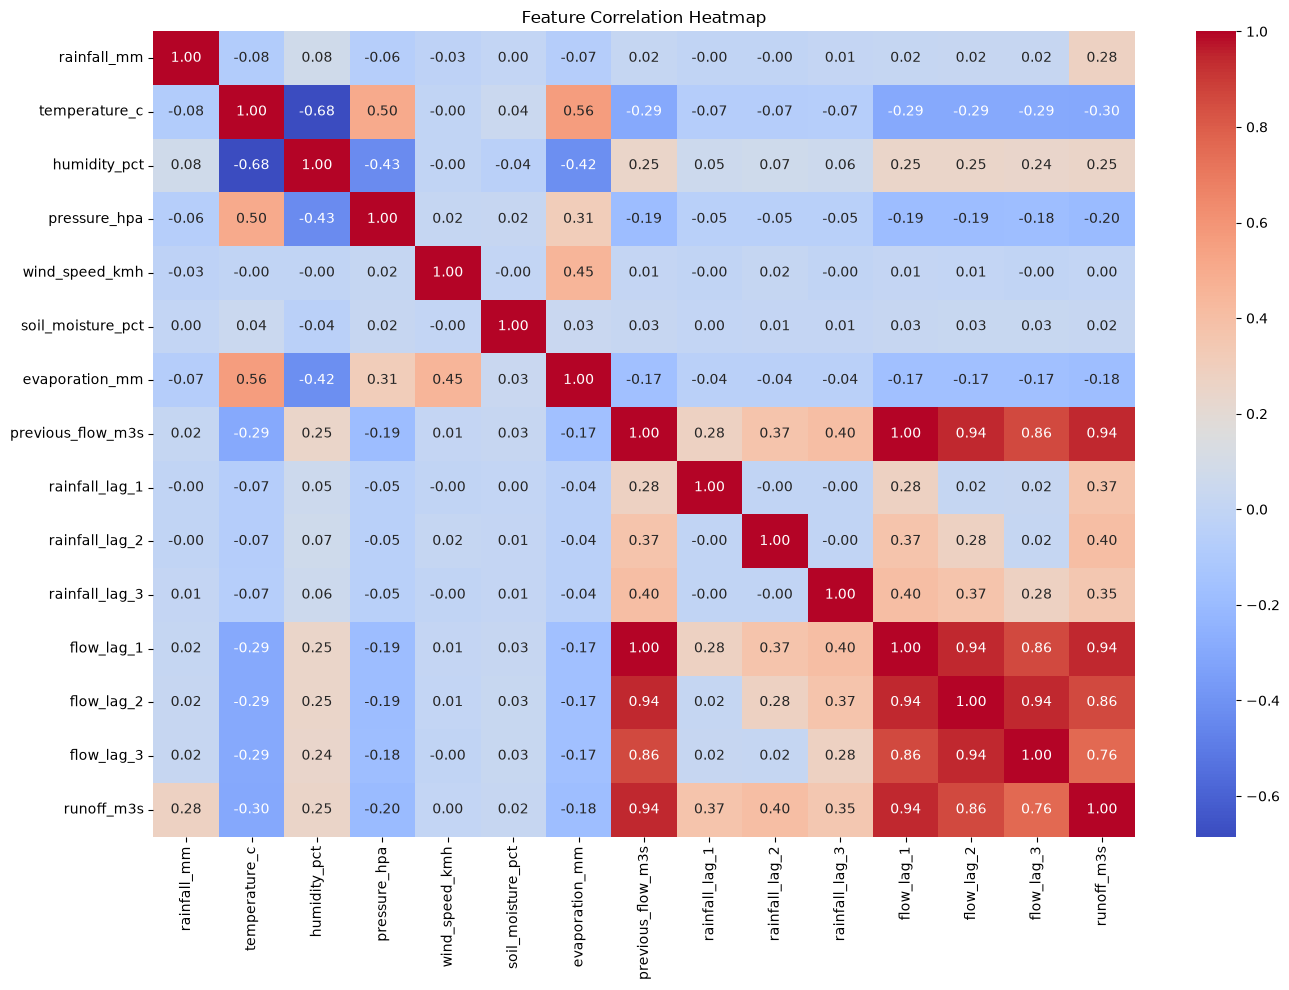

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png")
plt.show()

Define features and target

In [14]:
target = "runoff_m3s"

features = [
    "rainfall_mm",
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "wind_speed_kmh",
    "soil_moisture_pct",
    "evaporation_mm",
    "previous_flow_m3s",
    "rainfall_lag_1",
    "rainfall_lag_2",
    "rainfall_lag_3",
    "flow_lag_1",
    "flow_lag_2",
    "flow_lag_3"
]

X = df[features]

y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6000, 14)
y shape: (6000,)


Time-series train/test split

In [15]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training df:", X_train.shape)
print("Testing df:", X_test.shape)

Training df: (4800, 14)
Testing df: (1200, 14)


Create evaluation function

In [17]:
results = []


def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

Linear Regression

In [18]:
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)


Linear Regression
----------------------------------------
MAE  : 2.8016
RMSE : 3.5014
R²   : 0.9830


Random Forest

In [19]:
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


Random Forest
----------------------------------------
MAE  : 3.3212
RMSE : 5.0439
R²   : 0.9648


XGB boost

In [20]:
xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)


XGBoost
----------------------------------------
MAE  : 3.2481
RMSE : 4.8592
R²   : 0.9673


Gaussian Process Regression

In [21]:
gpr_train_size = min(1500, len(X_train))

X_gpr = X_train.iloc[:gpr_train_size]
y_gpr = y_train.iloc[:gpr_train_size]

gpr_imputer = SimpleImputer(strategy="median")

X_gpr_clean = gpr_imputer.fit_transform(X_gpr)
X_gpr_test_clean = gpr_imputer.transform(X_test)

gpr_scaler = StandardScaler()

X_gpr_scaled = gpr_scaler.fit_transform(X_gpr_clean)
X_gpr_test_scaled = gpr_scaler.transform(X_gpr_test_clean)

kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(1.0, (1e-2, 1e2))
)

gpr_model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    random_state=42
)

gpr_model.fit(
    X_gpr_scaled,
    y_gpr
)

gpr_pred, gpr_std = gpr_model.predict(
    X_gpr_test_scaled,
    return_std=True
)

evaluate_model(
    "GPR",
    y_test,
    gpr_pred
)


GPR
----------------------------------------
MAE  : 2.8407
RMSE : 3.5678
R²   : 0.9824


Artificial Neural Network

In [22]:
ann_imputer = SimpleImputer(strategy="median")

X_train_ann = ann_imputer.fit_transform(X_train)
X_test_ann = ann_imputer.transform(X_test)

ann_scaler = StandardScaler()

X_train_ann = ann_scaler.fit_transform(X_train_ann)
X_test_ann = ann_scaler.transform(X_test_ann)

y_train_ann = y_train.values
y_test_ann = y_test.values

In [23]:
ann_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_ann.shape[1],)),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

ann_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

ann_history = ann_model.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 846.9014 - mae: 20.9272 - val_loss: 88.7813 - val_mae: 7.6330
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 114.0219 - mae: 8.1667 - val_loss: 60.5929 - val_mae: 6.2661
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 77.8308 - mae: 6.7608 - val_loss: 43.4495 - val_mae: 5.2430
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 56.8078 - mae: 5.8371 - val_loss: 28.8872 - val_mae: 4.2251
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 49.6213 - mae: 5.3703 - val_loss: 24.7623 - val_mae: 3.9536
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 43.0162 - mae: 5.0157 - val_loss: 21.8886 - val_mae: 3.7277
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 40.4279 - mae: 4.8601 - val_loss: 18.0405 - val_mae: 3.3389
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 39.2313 - mae: 4.7260 - val_loss: 18.2292 - val_mae: 3.3687
Epoch 9/100
128/128 ━━

In [25]:
ann_pred = ann_model.predict(
    X_test_ann,
    verbose=0
).flatten()

evaluate_model(
    "ANN",
    y_test,
    ann_pred
)


ANN
----------------------------------------
MAE  : 3.0735
RMSE : 3.8313
R²   : 0.9797


LSTM

In [28]:
lstm_features = [
    "rainfall_mm",
    "temperature_c",
    "humidity_pct",
    "soil_moisture_pct",
    "previous_flow_m3s"
]

lstm_data = df[lstm_features + ["runoff_m3s"]].copy()

lstm_imputer = SimpleImputer(strategy="median")

lstm_features_clean = lstm_imputer.fit_transform(
    lstm_data[lstm_features]
)

lstm_target = lstm_data["runoff_m3s"].values

select features for LSTM model

In [30]:
lstm_features = [
    "rainfall_mm",
    "temperature_c",
    "humidity_pct",
    "soil_moisture_pct",
    "previous_flow_m3s"
]

lstm_data = df[lstm_features + ["runoff_m3s"]].copy()

lstm_imputer = SimpleImputer(strategy="median")

lstm_features_clean = lstm_imputer.fit_transform(
    lstm_data[lstm_features]
)

lstm_target = lstm_data["runoff_m3s"].values

create sequence

In [32]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select features and target
lstm_features = X.copy()
lstm_target = y.copy()

# Handle missing values
lstm_imputer = SimpleImputer(strategy="median")

lstm_features_clean = lstm_imputer.fit_transform(
    lstm_features
)

# Scale the features
lstm_scaler = StandardScaler()

lstm_features_scaled = lstm_scaler.fit_transform(
    lstm_features_clean
)

# Sequence length
sequence_length = 7

X_sequences = []
y_sequences = []

# Create sequences
for i in range(sequence_length, len(lstm_features_scaled)):

    X_sequences.append(
        lstm_features_scaled[i-sequence_length:i]
    )

    y_sequences.append(
        lstm_target.iloc[i]
    )

# Convert to NumPy arrays
X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("LSTM X shape:", X_sequences.shape)
print("LSTM y shape:", y_sequences.shape)

LSTM X shape: (5993, 7, 14)
LSTM y shape: (5993,)


Split LSTM data chronologically

In [33]:
lstm_split = int(len(X_sequences) * 0.80)

X_lstm_train = X_sequences[:lstm_split]
X_lstm_test = X_sequences[lstm_split:]

y_lstm_train = y_sequences[:lstm_split]
y_lstm_test = y_sequences[lstm_split:]

print(X_lstm_train.shape)
print(X_lstm_test.shape)

(4794, 7, 14)
(1199, 7, 14)


Build LSTM model

In [34]:
lstm_model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_lstm_train.shape[1],
            X_lstm_train.shape[2]
        )
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [35]:
lstm_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_split=0.15,
    epochs=80,
    batch_size=32,
    callbacks=[lstm_early_stop],
    verbose=1
)

Epoch 1/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 1632.7554 - mae: 33.0540 - val_loss: 656.3049 - val_mae: 19.2976
Epoch 2/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 880.1947 - mae: 22.3076 - val_loss: 371.1585 - val_mae: 14.3071
Epoch 3/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 622.9889 - mae: 18.9778 - val_loss: 351.7047 - val_mae: 15.0186
Epoch 4/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 406.0013 - mae: 13.8891 - val_loss: 142.5938 - val_mae: 8.3488
Epoch 5/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 245.1851 - mae: 10.0767 - val_loss: 98.1141 - val_mae: 7.3354
Epoch 6/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 177.2999 - mae: 8.4600 - val_loss: 74.7189 - val_mae: 6.5034
Epoch 7/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 147.5943 - mae: 7.8677 - val_loss: 68.2099 - val_mae: 6.2915
Epoch 8/80
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 130.8709 - mae: 7.4724 - val_loss: 58.4074 - val_mae: 5.6908
Epoch 9/80

In [36]:
lstm_pred = lstm_model.predict(
    X_lstm_test,
    verbose=0
).flatten()

evaluate_model(
    "LSTM",
    y_lstm_test,
    lstm_pred
)


LSTM
----------------------------------------
MAE  : 6.1465
RMSE : 9.5244
R²   : 0.8745


Compare all models

In [37]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
)

print("\nFINAL MODEL COMPARISON")
print("=" * 60)

print(
    results_df.to_string(index=False)
)

results_df.to_csv(
    "model_comparison.csv",
    index=False
)


FINAL MODEL COMPARISON
            Model      MAE     RMSE       R2
Linear Regression 2.801612 3.501358 0.983028
              GPR 2.840706 3.567813 0.982378
              ANN 3.073497 3.831270 0.979680
          XGBoost 3.248103 4.859180 0.967313
    Random Forest 3.321187 5.043909 0.964781
             LSTM 6.146512 9.524363 0.874470


Actual vs Predicted Graph

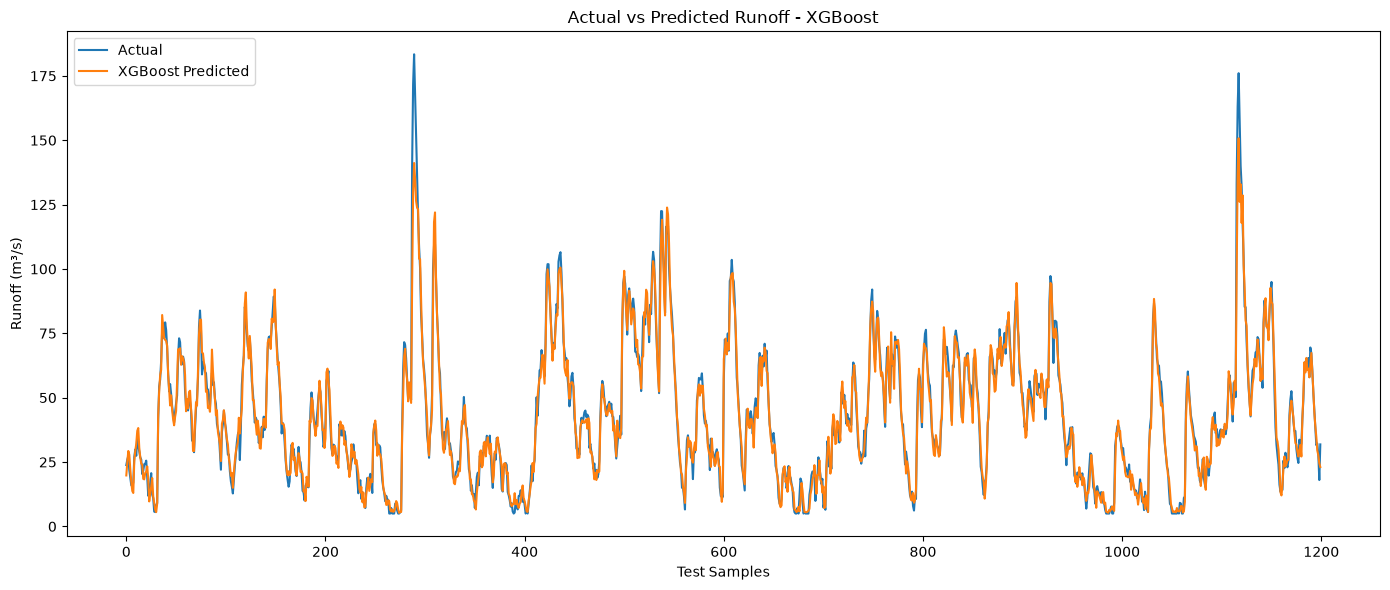

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    xgb_pred,
    label="XGBoost Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Runoff (m³/s)")
plt.title("Actual vs Predicted Runoff - XGBoost")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/xgboost_actual_vs_predicted.png"
)

plt.show()

Feature Importance

In [39]:
rf_estimator = rf_model.named_steps["model"]

importance = rf_estimator.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
7   previous_flow_m3s    0.464388
11         flow_lag_1    0.430569
0         rainfall_mm    0.068372
8      rainfall_lag_1    0.009876
13         flow_lag_3    0.005241
12         flow_lag_2    0.004088
6      evaporation_mm    0.003120
9      rainfall_lag_2    0.003019
3        pressure_hpa    0.002734
4      wind_speed_kmh    0.002563
2        humidity_pct    0.002532
1       temperature_c    0.002492
10     rainfall_lag_3    0.000992
5   soil_moisture_pct    0.000014


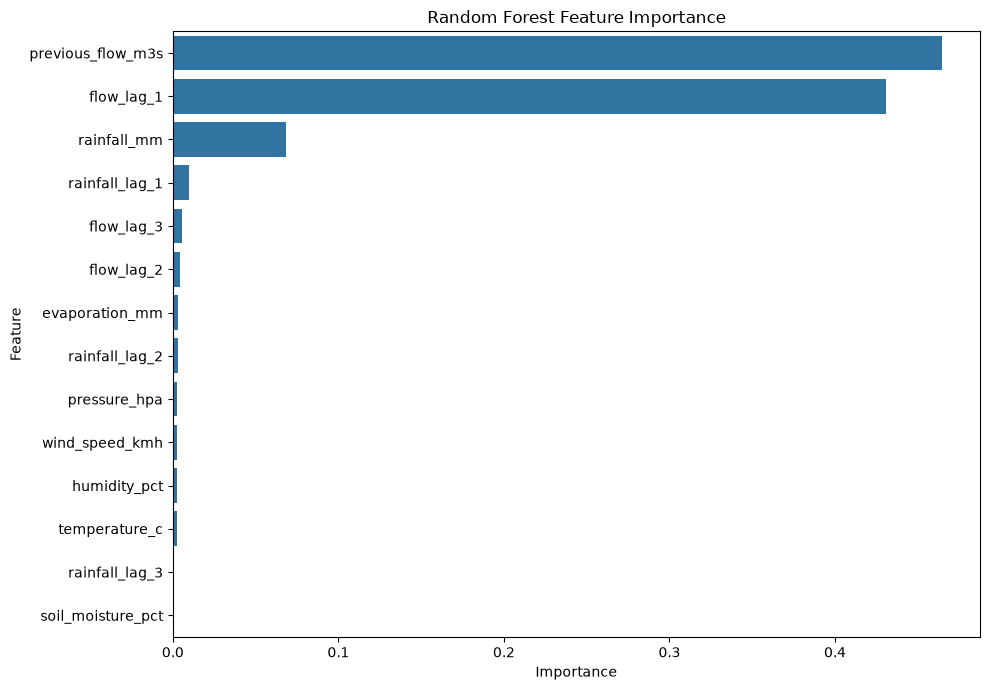

In [40]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "plots/random_forest_feature_importance.png"
)

plt.show()

Save your models

In [41]:
joblib.dump(
    linear_model,
    "models/linear_regression.pkl"
)

joblib.dump(
    rf_model,
    "models/random_forest.pkl"
)

joblib.dump(
    xgb_model,
    "models/xgboost.pkl"
)

joblib.dump(
    gpr_model,
    "models/gpr.pkl"
)

joblib.dump(
    gpr_imputer,
    "models/gpr_imputer.pkl"
)

joblib.dump(
    gpr_scaler,
    "models/gpr_scaler.pkl"
)

['models/gpr_scaler.pkl']

In [57]:
# train_and_save.py
import os
import warnings
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
os.makedirs("models", exist_ok=True)
np.random.seed(42)
tf.random.set_seed(42)

# Load Data
data = pd.read_csv("rainfall_runoff.csv")
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

FEATURES = [
    "rainfall_mm", "temperature_c", "humidity_pct", "pressure_hpa",
    "wind_speed_kmh", "soil_moisture_pct", "evaporation_mm",
    "previous_flow_m3s", "rainfall_lag_1", "rainfall_lag_2",
    "rainfall_lag_3", "flow_lag_1", "flow_lag_2", "flow_lag_3"
]
TARGET = "runoff_m3s"

X = data[FEATURES]
y = data[TARGET]

split_idx = int(len(data) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

results = []

def eval_and_record(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

# 1. Linear Regression
lr = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LinearRegression())])
lr.fit(X_train, y_train)
eval_and_record("Linear Regression", y_test, lr.predict(X_test))
joblib.dump(lr, "models/linear_regression.pkl")

# 2. Random Forest
rf = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
eval_and_record("Random Forest", y_test, rf.predict(X_test))
joblib.dump(rf, "models/random_forest.pkl")

# 3. XGBoost
xgb = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))])
xgb.fit(X_train, y_train)
eval_and_record("XGBoost", y_test, xgb.predict(X_test))
joblib.dump(xgb, "models/xgboost.pkl")

# 4. GPR
gpr_train_size = min(1500, len(X_train))
X_gpr = X_train.iloc[:gpr_train_size]
y_gpr = y_train.iloc[:gpr_train_size]
gpr_imp = SimpleImputer(strategy="median")
X_gpr_c = gpr_imp.fit_transform(X_gpr)
gpr_scl = StandardScaler()
X_gpr_s = gpr_scl.fit_transform(X_gpr_c)
gpr = GaussianProcessRegressor(kernel=C(1.0)*RBF(1.0), alpha=1e-2, normalize_y=True, random_state=42)
gpr.fit(X_gpr_s, y_gpr)

X_test_gpr_s = gpr_scl.transform(gpr_imp.transform(X_test))
eval_and_record("GPR", y_test, gpr.predict(X_test_gpr_s))
joblib.dump(gpr, "models/gpr.pkl")

# Save Metrics
pd.DataFrame(results).to_csv("model_comparison.csv", index=False)
print("Training Complete! Models and metrics saved successfully.")

Training Complete! Models and metrics saved successfully.


In [65]:
models["Linear Regression"] = joblib.load(
    "linear_regression.pkl"
)

In [66]:
models["Random Forest"] = joblib.load(
    "random_forest.pkl"
)

models["XGBoost"] = joblib.load(
    "xgboost.pkl"
)

In [67]:
@st.cache_resource
def load_models():

    models = {}

    if os.path.exists("linear_regression.pkl"):
        models["Linear Regression"] = joblib.load(
            "linear_regression.pkl"
        )

    if os.path.exists("random_forest.pkl"):
        models["Random Forest"] = joblib.load(
            "random_forest.pkl"
        )

    if os.path.exists("xgboost.pkl"):
        models["XGBoost"] = joblib.load(
            "xgboost.pkl"
        )

    return models

In [68]:
df = pd.read_csv("rainfall_runoff.csv")

In [72]:
# -------------------------------------------------
# RANDOM FOREST FEATURE IMPORTANCE
# -------------------------------------------------

if "Random Forest" in models:

    st.subheader(
        "🌲 Random Forest Feature Importance"
    )

    rf_model = models["Random Forest"]

    # Check if model is a Pipeline
    if hasattr(rf_model, "named_steps"):

        if "model" in rf_model.named_steps:

            rf_model = rf_model.named_steps["model"]

    # Check feature importance
    if hasattr(rf_model, "feature_importances_"):

        importance = rf_model.feature_importances_

        importance_df = pd.DataFrame({
            "Feature": FEATURES,
            "Importance": importance
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=True
        )

        fig_importance = px.bar(
            importance_df,
            x="Importance",
            y="Feature",
            orientation="h",
            title="Random Forest Feature Importance"
        )

        st.plotly_chart(
            fig_importance,
            use_container_width=True
        )

    else:

        st.warning(
            "Feature importance is not available for this model."
        )

2026-09-01 20:56:45.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 20:56:45.503 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 20:56:45.503 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 20:56:46.663 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 20:56:46.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 20:56:46.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 20:56:46.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [73]:
@st.cache_resource
def load_models():

    models = {}

    try:
        if LINEAR_MODEL_PATH.exists():
            models["Linear Regression"] = joblib.load(
                LINEAR_MODEL_PATH
            )

        if RF_MODEL_PATH.exists():
            models["Random Forest"] = joblib.load(
                RF_MODEL_PATH
            )

        if XGB_MODEL_PATH.exists():
            models["XGBoost"] = joblib.load(
                XGB_MODEL_PATH
            )

    except Exception as e:

        st.error(
            f"Error loading models: {e}"
        )

    return models

In [77]:
import os
import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st

# Explicitly import XGBoost so joblib can unpickle xgboost.pkl
try:
    import xgboost as xgb
except ImportError:
    xgb = None

# ... [Keep your page config and FEATURES unchanged] ...

@st.cache_resource
def load_models():
    models = {}
    
    model_files = {
        "Linear Regression": ["linear_regression.pkl", "models/linear_regression.pkl"],
        "Random Forest": ["random_forest.pkl", "models/random_forest.pkl"],
        "XGBoost": ["xgboost.pkl", "models/xgboost.pkl"],
        "GPR": ["gpr.pkl", "models/gpr.pkl"]
    }

    for model_name, paths in model_files.items():
        if model_name == "XGBoost" and xgb is None:
            st.sidebar.warning("⚠️ XGBoost module not installed. Run `pip install xgboost`.")
            continue
            
        for path in paths:
            if os.path.exists(path):
                try:
                    models[model_name] = joblib.load(path)
                    break
                except Exception as e:
                    st.sidebar.warning(f"Could not load {model_name} from {path}: {e}")
                    
    return models